In [52]:
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
from PIL import Image
from google.colab import files

plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams.update({'font.size': 18})

mat_contents = scipy.io.loadmat('allFaces.mat')
faces = mat_contents['faces']
m = int(mat_contents['m'][0,0])
n = int(mat_contents['n'][0,0])
nfaces = np.ndarray.flatten(mat_contents['nfaces'])

trainingFaces = faces[:,:np.sum(nfaces[:36])]
avgFace = np.mean(trainingFaces,axis=1)

X = trainingFaces - np.tile(avgFace,(trainingFaces.shape[1],1)).T
U, S, VT = np.linalg.svd(X,full_matrices=0)

In [53]:
k = 25

cum_singular = np.cumsum(S)
cum_share = cum_singular / np.sum(S)

r = np.argmax(cum_share > k/100) + 1

print("Wariant k =", k, "%")
print("Minimalne r =", r)
print("Zachowany udział informacji =", cum_share[r-1]*100, "%")

Wariant k = 25 %
Minimalne r = 17
Zachowany udział informacji = 25.018919697975168 %


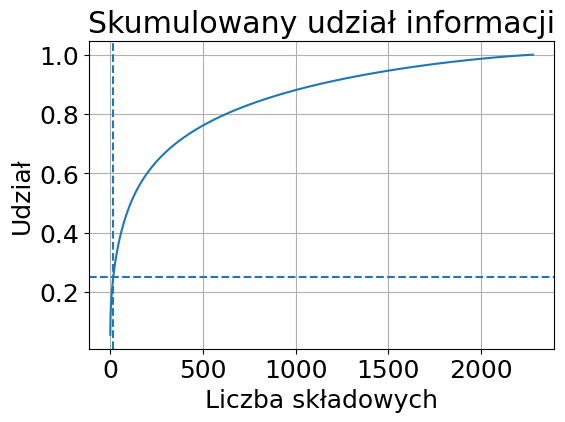

In [54]:
plt.figure(figsize=(6,4))
plt.plot(cum_share)
plt.axhline(k/100, linestyle='--')
plt.axvline(r, linestyle='--')
plt.title("Skumulowany udział informacji")
plt.xlabel("Liczba składowych")
plt.ylabel("Udział")
plt.grid(True)
plt.show()

In [55]:
uploaded = files.upload()

Saving mojezdjecie.jpg to mojezdjecie.jpg


In [56]:
from PIL import Image, ImageOps

img = Image.open('mojezdjecie.jpg').convert('L')
img = ImageOps.exif_transpose(img)
img = img.resize((m, n))

img_arr = np.array(img, dtype=np.float64)
myFace = img_arr.T.reshape(m*n)

In [57]:
myFaceMS = myFace - avgFace
reconFace = avgFace + U[:,:r] @ U[:,:r].T @ myFaceMS

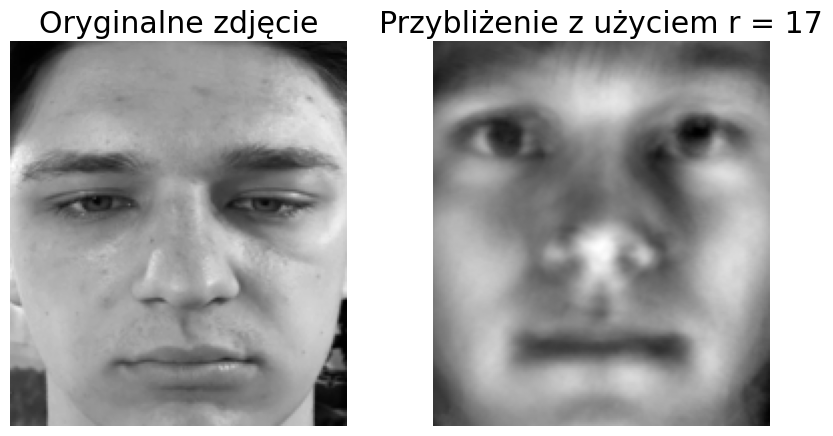

In [58]:
fig = plt.figure(figsize=(10,5))

ax1 = fig.add_subplot(121)
img1 = ax1.imshow(np.reshape(myFace,(m,n)).T)
img1.set_cmap('gray')
ax1.set_title('Oryginalne zdjęcie')
ax1.axis('off')

ax2 = fig.add_subplot(122)
img2 = ax2.imshow(np.reshape(reconFace,(m,n)).T)
img2.set_cmap('gray')
ax2.set_title('Przybliżenie z użyciem r = ' + str(r))
ax2.axis('off')

plt.show()